In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")


Read Data

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("naeem41/cicids2017-dataset")

# print("Path to dataset files:", path)

In [5]:
# import os

# for root, dirs, files in os.walk(path):
#     for file in files:
#         print(os.path.join(root, file))

In [27]:
df_data = pd.read_csv("combinenew.csv")
df_data.shape

(2830744, 79)

Show Data

In [4]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


Information About Data And Describe Data

In [5]:
df_data.info(show_counts=True)
# Target => Label => Str
# Destination Port => Object
# Remaining Data => Float

<class 'pandas.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             2830744 non-null  object 
 1    Flow Duration                2830743 non-null  float64
 2    Total Fwd Packets            2830743 non-null  float64
 3    Total Backward Packets       2830743 non-null  float64
 4   Total Length of Fwd Packets   2830743 non-null  float64
 5    Total Length of Bwd Packets  2830743 non-null  float64
 6    Fwd Packet Length Max        2830743 non-null  float64
 7    Fwd Packet Length Min        2830743 non-null  float64
 8    Fwd Packet Length Mean       2830743 non-null  float64
 9    Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max         2830743 non-null  float64
 11   Bwd Packet Length Min        2830743 non-null  float64
 12   Bwd Packet Length Mean       2830743 n

In [6]:
df_data.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,8.708495e+02,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,7.900000e+01,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,2.800000e+02,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,1.953000e+04,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [7]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [8]:
df_data = df_data.round(2)

In [9]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [10]:
df_data.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820196e+01,6.891003e+01,8.708495e+02,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,7.900000e+01,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616000e+01,2.800000e+02,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940860e+03,7.125600e+03,1.953000e+04,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [11]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


Check About Dublicates

In [12]:
df_data.duplicated().sum()

np.int64(330513)

Old => There is 330406 duplicated we will remove , New => 330513

In [13]:
df_data.drop_duplicates(inplace=True) # Drop Duplicates

df_data.duplicated().sum() # Check Again

np.int64(0)

In [14]:
df_data.shape # The Shape Data After Drop Duplicates

(2500231, 79)

Check Null Values

In [15]:
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)
df_data.replace(['?', 'unknown', 'Unknown', 'UNKNOWN', 'None', 'none', ' '], np.nan, inplace=True)
print(df_data.isnull().sum().to_string())

 Destination Port                  0
 Flow Duration                     1
 Total Fwd Packets                 1
 Total Backward Packets            1
Total Length of Fwd Packets        1
 Total Length of Bwd Packets       1
 Fwd Packet Length Max             1
 Fwd Packet Length Min             1
 Fwd Packet Length Mean            1
 Fwd Packet Length Std             1
Bwd Packet Length Max              1
 Bwd Packet Length Min             1
 Bwd Packet Length Mean            1
 Bwd Packet Length Std             1
Flow Bytes/s                    1542
 Flow Packets/s                 1538
 Flow IAT Mean                     1
 Flow IAT Std                      1
 Flow IAT Max                      1
 Flow IAT Min                      1
Fwd IAT Total                      1
 Fwd IAT Mean                      1
 Fwd IAT Std                       1
 Fwd IAT Max                       1
 Fwd IAT Min                       1
Bwd IAT Total                      1
 Bwd IAT Mean                      1
 

Null Values Is Very Low We Will Drop it

In [56]:
df_data.dropna(inplace=True)
# Check
print(df_data.isnull().sum().to_string())

Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Bwd IAT Max                    0
Bwd IAT Min                    0
Fwd PSH Flags                  0
Fwd Header

In [17]:
# Destination Port => object , but we want it to be int.
df_data.columns = df_data.columns.str.strip()
df_data['Destination Port'] = pd.to_numeric(df_data['Destination Port'], errors='coerce')
df_data.dropna(subset=['Destination Port'], inplace=True)
df_data['Destination Port'] = df_data['Destination Port'].astype(int)


df_data.reset_index(drop=True, inplace=True)

print(df_data['Destination Port'].dtype)
print("Shape:", df_data.shape)

int64
Shape: (2498689, 79)


Quick-iteration sample: this keeps every Label's share of the data the same (stratified), just with fewer rows, so the dataset still looks like the full one. Set `SAMPLE_FRACTION = 1.0` before your final run to switch back to the full dataset.

In [29]:
print(list(df_data.columns))

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [30]:
# SAMPLE_FRACTION = 0.25

# df_data = (
#     df_data.groupby('Label', group_keys=False)
#     .apply(lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=42))
#     .reset_index(drop=True)
# )

# print("Shape after sampling:", df_data.shape)
# print(df_data['Label'].value_counts(normalize=True).round(4))
df_data.columns = df_data.columns.str.strip()
SAMPLE_FRACTION = 0.25

df_data = (
    df_data.groupby('Label')
    .sample(frac=SAMPLE_FRACTION, random_state=42)
    .reset_index(drop=True)
)

print("Shape after sampling:", df_data.shape)
print(df_data['Label'].value_counts(normalize=True).round(4))

Shape after sampling: (707685, 79)
Label
BENIGN                      0.8030
DoS Hulk                    0.0816
PortScan                    0.0561
DDoS                        0.0452
DoS GoldenEye               0.0036
FTP-Patator                 0.0028
SSH-Patator                 0.0021
DoS slowloris               0.0020
DoS Slowhttptest            0.0019
Bot                         0.0007
Web Attack_Brute Force      0.0005
Web Attack_XSS              0.0002
Infiltration                0.0000
Web Attack_Sql Injection    0.0000
Heartbleed                  0.0000
Name: proportion, dtype: float64


Remove Zero-Variance Columns

Note: these columns are almost always 0, so they carry no signal. This is a low-variance issue, not data leakage.

In [ ]:
df_data.columns = df_data.columns.str.strip()
col_zero = [

    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bytes/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bulk Rate",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd URG Flags",
    "CWE Flag Count",
    #OS Fingerprinting
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward'
]
zero_pct = (df_data[col_zero].replace(0, np.nan).isnull().sum() / len(df_data)) * 100
print(zero_pct)


KeyError: "None of [Index(['Fwd Avg Packets/Bulk', 'Fwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk',\n       'Bwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bulk Rate',\n       'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd URG Flags', 'CWE Flag Count',\n       'Init_Win_bytes_forward', 'Init_Win_bytes_backward'],\n      dtype='str')] are in the [columns]"

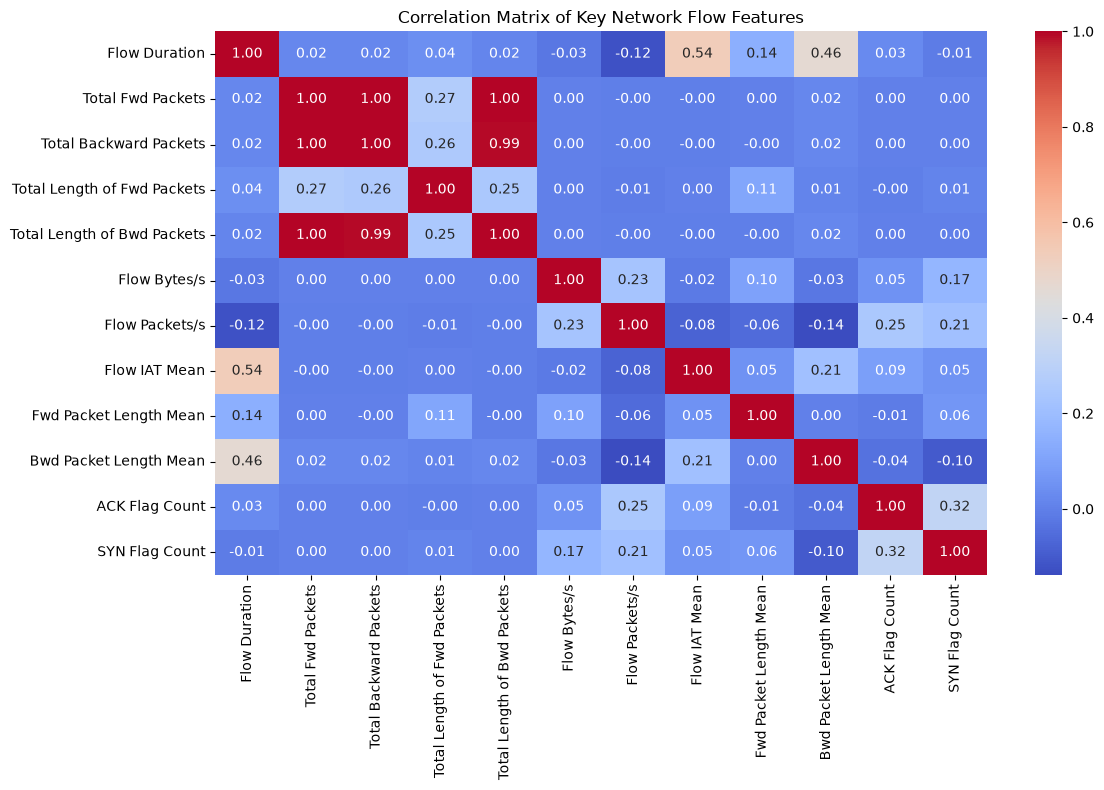

In [33]:
# Check Heatmap Again
key_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'ACK Flag Count', 'SYN Flag Count'
]
plt.figure(figsize=(12, 8))
corr = df_data[key_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Key Network Flow Features")
plt.tight_layout()
plt.show()

In [34]:
df_data.drop(columns=col_zero, inplace=True)
print("Shape:", df_data.shape)

Shape: (707685, 67)


In [35]:
df_data.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'ECE Flag Count',
 'Down/Up Ratio',
 '

In [36]:
non_negative_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'min_seg_size_forward', 'act_data_pkt_fwd',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
non_negative_cols = [c for c in non_negative_cols if c in df_data.columns]

bad_row_mask = (df_data[non_negative_cols] < 0).any(axis=1)
bad_row_mask.sum() #number of invalid negative vals in columns

np.int64(733)

In [37]:
df_data = df_data.loc[~bad_row_mask].reset_index(drop=True)
df_data.shape

(706952, 67)

Check Class Distribution (Label)

In [38]:
label_counts = df_data['Label'].value_counts()
label_percentage = df_data['Label'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({'Count': label_counts, 'Percentage': label_percentage.round(3)})
print(distribution)

                           Count  Percentage
Label                                       
BENIGN                    567589      80.287
DoS Hulk                   57729       8.166
PortScan                   39732       5.620
DDoS                       32001       4.527
DoS GoldenEye               2572       0.364
FTP-Patator                 1984       0.281
SSH-Patator                 1473       0.208
DoS slowloris               1449       0.205
DoS Slowhttptest            1375       0.194
Bot                          492       0.070
Web Attack_Brute Force       377       0.053
Web Attack_XSS               163       0.023
Infiltration                   8       0.001
Web Attack_Sql Injection       5       0.001
Heartbleed                     3       0.000


The dataset is highly imbalanced (BENIGN dominates)

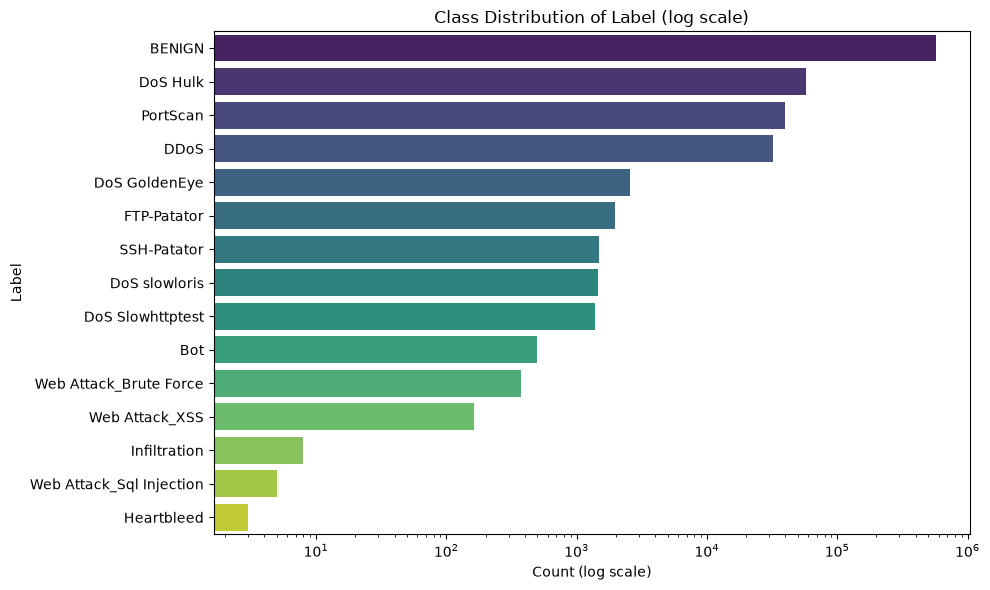

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('Label')
plt.title('Class Distribution of Label (log scale)')
plt.tight_layout()
plt.show()

## EDA

#### Correlation matrix across all numeric features (not just a manual subset)

In [30]:
# numeric_df = df_data.select_dtypes(include=[np.number]).drop(columns=['Destination Port'], errors='ignore')

# full_corr = numeric_df.corr().abs()

# plt.figure(figsize=(20, 16))
# sns.heatmap(full_corr, cmap="coolwarm", cbar=True)
# plt.title("Correlation Matrix - All Numeric Features")
# plt.tight_layout()
# plt.show()

#### Find redundant columns (correlation > 0.95), and check none of them are actually important to the target before dropping

In [31]:
# upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))

# threshold = 0.95
# to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

# temp_binary_label = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
# numeric_df_with_target = numeric_df.copy()
# numeric_df_with_target['Binary_Label'] = temp_binary_label

# target_corr = numeric_df_with_target[to_drop + ['Binary_Label']].corr()['Binary_Label']

# print(f"Number of columns to drop: {len(to_drop)}")
# print("\nCorrelation of dropped columns with target:")
# print(target_corr.sort_values(ascending=False))

#### Drop the redundant columns

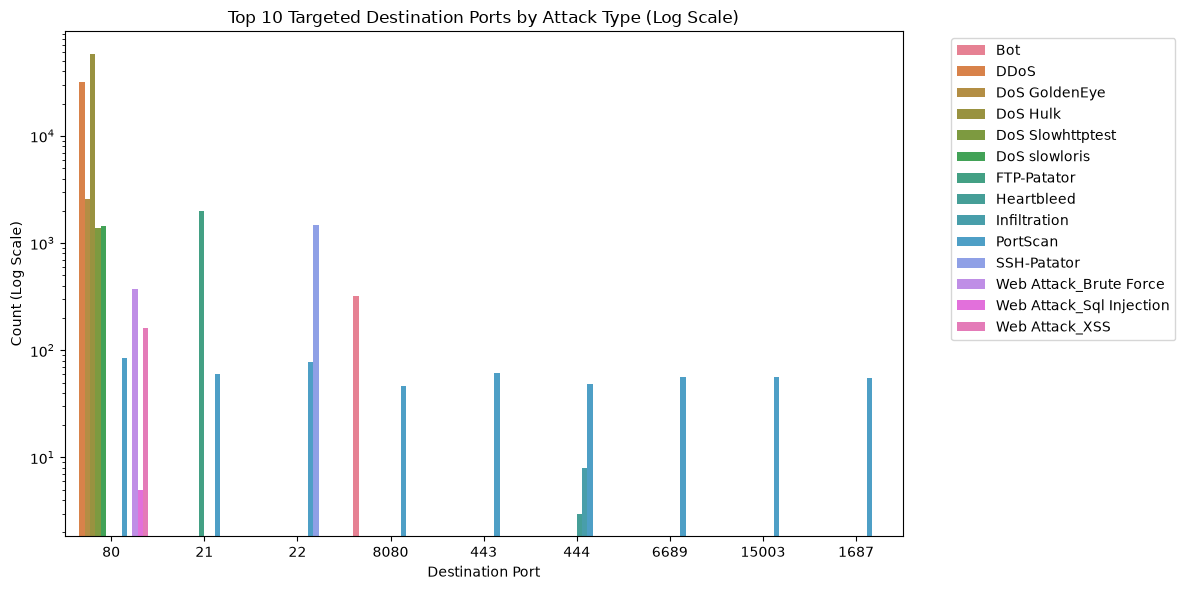

In [40]:
attack_df = df_data[df_data['Label'] != 'BENIGN']
top_ports = attack_df['Destination Port'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=attack_df[attack_df['Destination Port'].isin(top_ports)],
    x='Destination Port',
    hue='Label',
    order=top_ports
)
plt.yscale('log')
plt.title('Top 10 Targeted Destination Ports by Attack Type (Log Scale)')
plt.xlabel('Destination Port')
plt.ylabel('Count (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

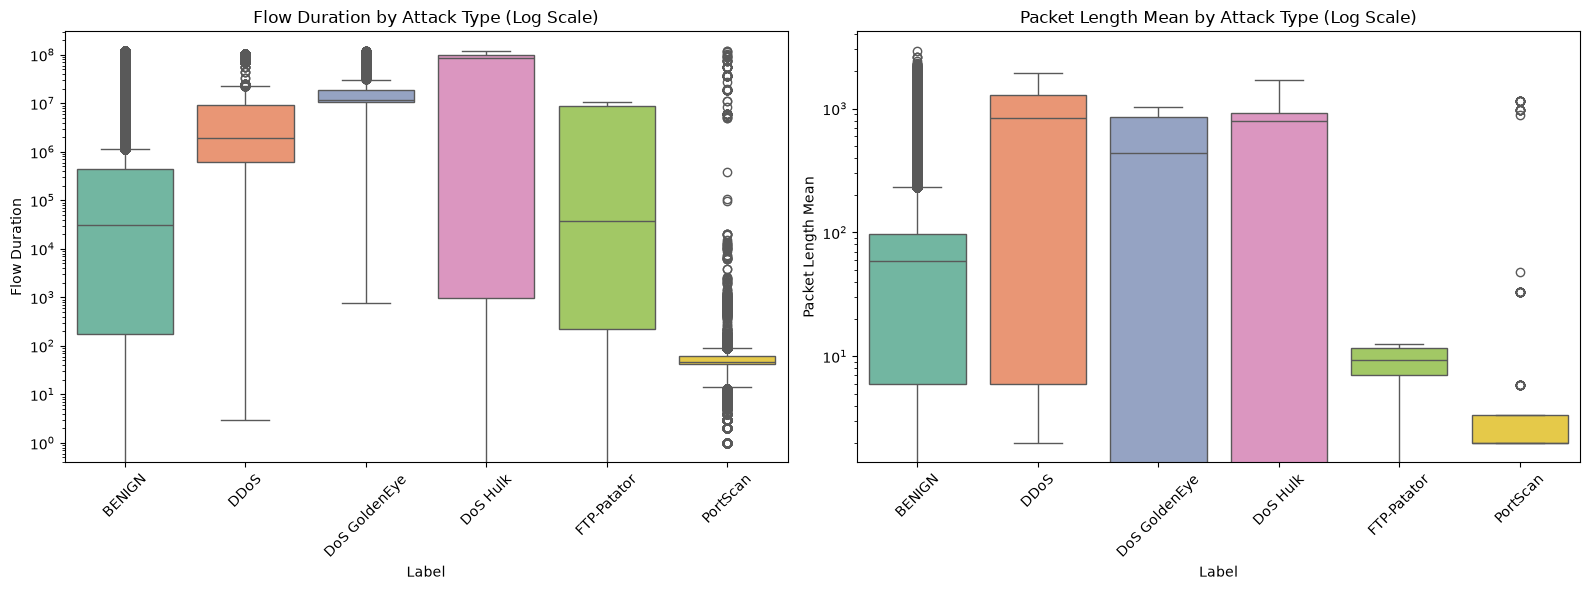

In [41]:
top_labels = df_data['Label'].value_counts().head(6).index
df_subset = df_data[df_data['Label'].isin(top_labels)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df_subset, x='Label', y='Flow Duration', palette='Set2')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration by Attack Type (Log Scale)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(ax=axes[1], data=df_subset, x='Label', y='Packet Length Mean', palette='Set2')
axes[1].set_yscale('log')
axes[1].set_title('Packet Length Mean by Attack Type (Log Scale)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

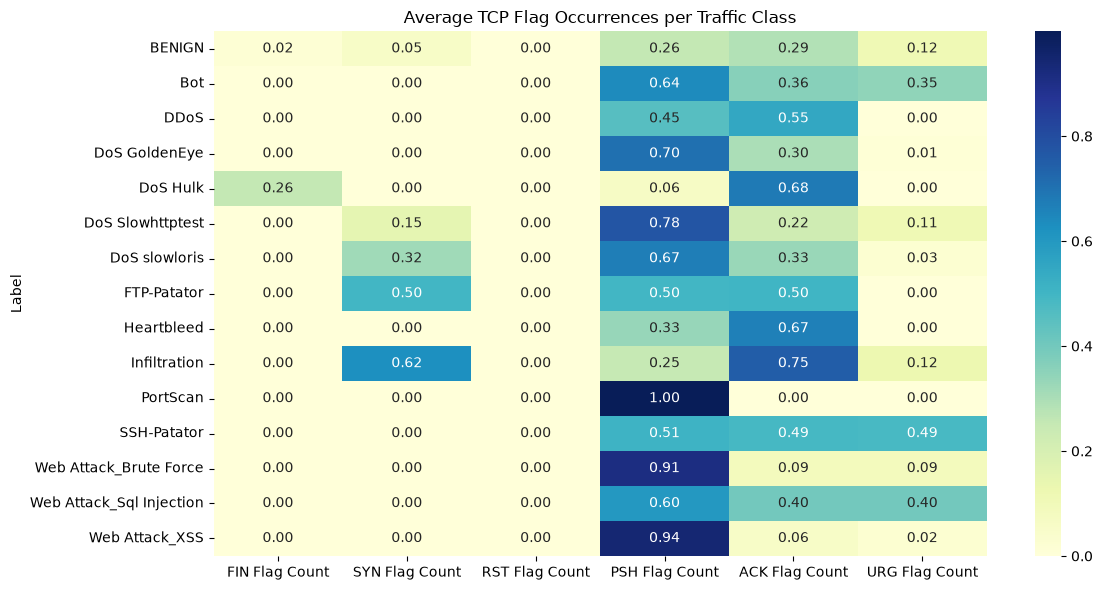

In [42]:
flag_cols = ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']
flag_summary = df_data.groupby('Label')[flag_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(flag_summary, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average TCP Flag Occurrences per Traffic Class")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

making dest ports into categories

In [46]:
# df_data.columns = df_data.columns.str.strip()

# df_data['Destination Port'] = pd.to_numeric(df_data['Destination Port'], errors='coerce')
# df_data.dropna(subset=['Destination Port'], inplace=True)


# def categorize_port(port):
#     if port <= 1023:
#         return 'Well_Known'
#     elif port <= 49151:
#         return 'Registered'
#     else:
#         return 'Dynamic'


# df_data['Port_Category'] = df_data['Destination Port'].apply(categorize_port)
# df_data = pd.get_dummies(df_data, columns=['Port_Category'], drop_first=True)

# df_data.drop(columns=['Destination Port'], inplace=True)
df_data.drop(columns=['Destination Port' , 'RST Flag Count'], inplace=True, errors='ignore')

Encode categorical labels to numeric values

In [47]:
le = LabelEncoder()
df_data['Label_Encoded'] = le.fit_transform(df_data['Label'])


Map to Binary (0: BENIGN, 1: ATTACK)

In [48]:
df_data['Binary_Label'] = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

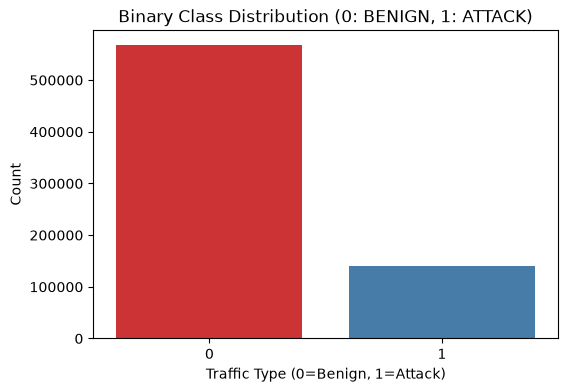

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_data, x='Binary_Label', palette='Set1', hue='Binary_Label', legend=False)
plt.title('Binary Class Distribution (0: BENIGN, 1: ATTACK)')
plt.xlabel('Traffic Type (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.show()

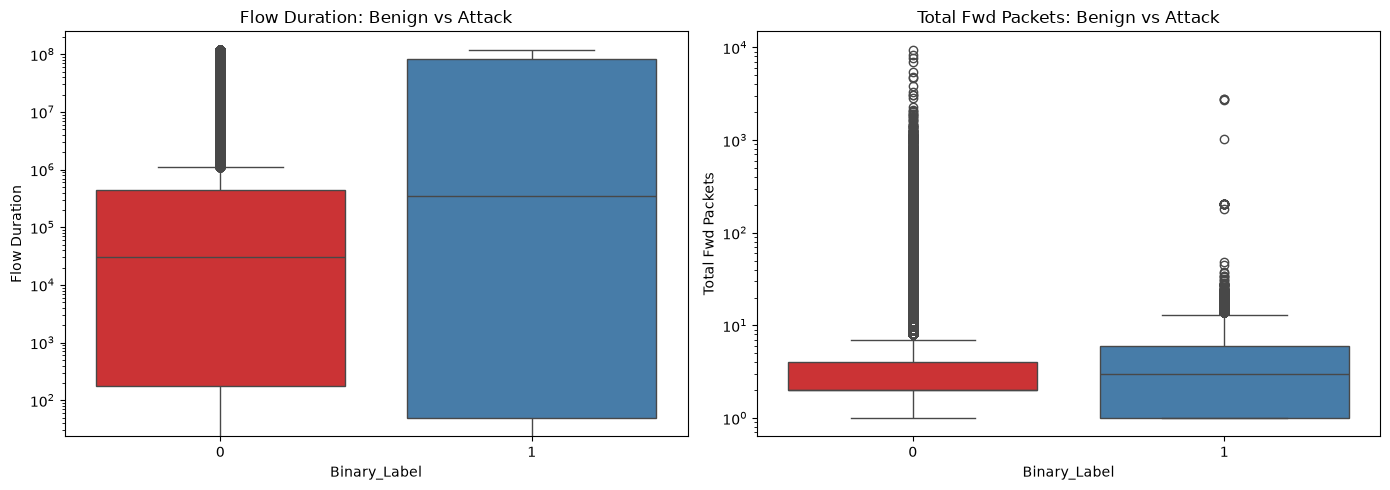

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=df_data, x='Binary_Label', y='Flow Duration', palette='Set1')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration: Benign vs Attack')

sns.boxplot(ax=axes[1], data=df_data, x='Binary_Label', y='Total Fwd Packets', palette='Set1')
axes[1].set_yscale('log')
axes[1].set_title('Total Fwd Packets: Benign vs Attack')

plt.tight_layout()
plt.show()

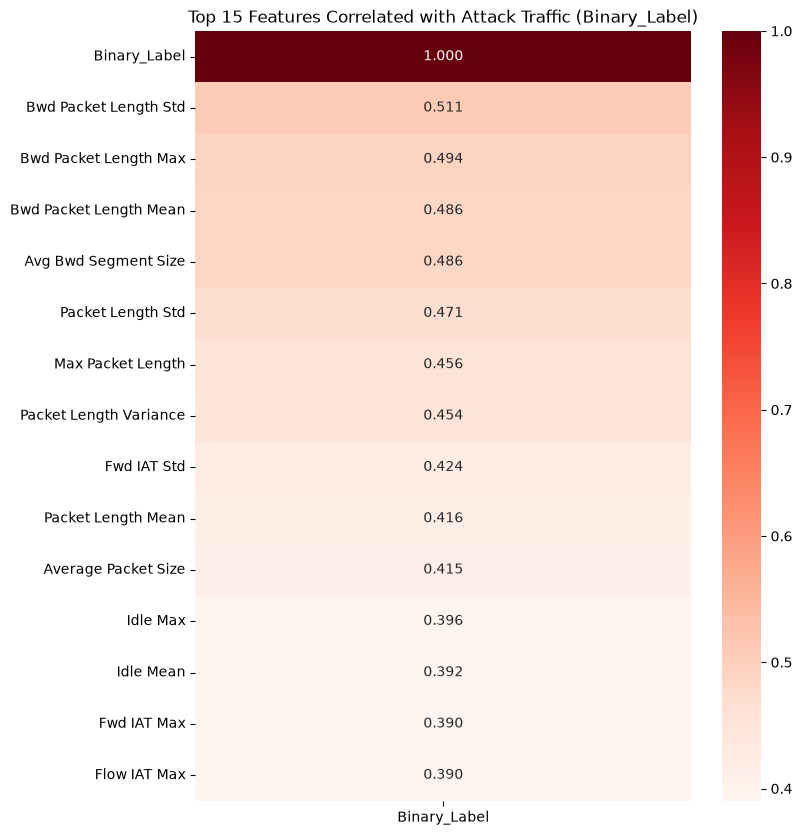

In [52]:
plt.figure(figsize=(8, 10))
# dropping string and multi class target to calculate correlation properly
binary_corr = df_data.drop(columns=['Label', 'Label_Encoded']).corr()[['Binary_Label']].sort_values(by='Binary_Label', ascending=False)
sns.heatmap(binary_corr.head(15), annot=True, cmap='Reds', fmt='.3f')
plt.title("Top 15 Features Correlated with Attack Traffic (Binary_Label)")
plt.show()

In [41]:
# df_data.drop(columns=['RST Flag Count'] , inplace=True , errors='ignore')

Bug fix: the redundant columns found above (correlation > 0.95, e.g. the duplicate `Fwd Header Length.1`) were identified but never actually dropped. Dropping them now, right before modeling, so the earlier EDA plots still use the full feature set.

In [42]:
# df_data.drop(columns=to_drop, inplace=True, errors='ignore')
# print("Shape after dropping redundant (>0.95 correlated) columns:", df_data.shape)

Feature, Target, and Group Definition


In [63]:
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)
df_data.dropna(inplace=True)


In [64]:
def build_flow_groups(df):
    candidate_columns = [
        'Session ID', 'SessionID', 'session_id',
        'Burst ID', 'BurstID', 'burst_id',
        'Flow ID', 'FlowID', 'flow_id'
    ]

    selected = [col for col in candidate_columns if col in df.columns]
    if selected:
        group_key = df[selected].astype(str).agg('||'.join, axis=1)
        return group_key, selected

    tuple_candidates = {
        'src_ip': ['Source IP', 'Src IP', 'src_ip'],
        'dst_ip': ['Destination IP', 'Dst IP', 'dst_ip'],
        'src_port': ['Source Port', 'Src Port', 'src_port'],
        'dst_port': ['Destination Port', 'Dst Port', 'dst_port'],
        'protocol': ['Protocol', 'protocol'],
    }

    picked = {}
    for key, options in tuple_candidates.items():
        for col in options:
            if col in df.columns:
                picked[key] = col
                break

    if len(picked) >= 4:
        base_key = df[list(picked.values())].astype(str).agg('||'.join, axis=1)
        timestamp_col = next((c for c in ['Timestamp', 'timestamp', 'Flow Start'] if c in df.columns), None)
        if timestamp_col is not None:
            ts = pd.to_datetime(df[timestamp_col], errors='coerce').dt.floor('1s').astype(str)
            base_key = base_key + '||' + ts
        return base_key, list(picked.values())

    fallback = pd.Series(df.index.astype(str), index=df.index)
    return fallback, ['row_index_fallback']

X = df_data.drop(columns=['Label', 'Label_Encoded', 'Binary_Label'], errors='ignore').copy()
y = df_data['Binary_Label'].copy()
groups, group_columns_used = build_flow_groups(df_data)

X = X.apply(pd.to_numeric, errors='coerce')
valid_mask = ~X.isna().any(axis=1)

X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)
groups = groups.loc[valid_mask].reset_index(drop=True)

print('Group columns used:', group_columns_used)
print('Unique groups:', groups.nunique())
print('Dataset shape after numeric cleaning:', X.shape)


In [65]:
non_numeric = X.select_dtypes(include=['object']).columns.tolist()
print('Non-numeric columns:', non_numeric)
print('Total NaN values:', X.isna().sum().sum())
print('Total Inf values:', np.isinf(X.select_dtypes(include=np.number)).values.sum())


Non-numeric columns: []
Total NaN values: 0
Total Inf values: 0


In [66]:
class DataFrameVarianceThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.0):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.selector_ = VarianceThreshold(threshold=self.threshold)
        self.selector_.fit(X)
        self.selected_columns_ = X.columns[self.selector_.get_support()]
        return self

    def transform(self, X):
        Xt = self.selector_.transform(X)
        return pd.DataFrame(Xt, columns=self.selected_columns_, index=X.index)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.to_drop_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.to_drop_, errors='ignore')


In [67]:
class DropColumnsContaining(BaseEstimator, TransformerMixin):
    def __init__(self, substring='Port_Category'):
        self.substring = substring

    def fit(self, X, y=None):
        self.to_drop_ = [col for col in X.columns if self.substring in col]
        return self

    def transform(self, X):
        return X.drop(columns=self.to_drop_, errors='ignore')


class MutualInfoTopKSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=40, random_state=42):
        self.k = k
        self.random_state = random_state

    def fit(self, X, y):
        mi_scores = mutual_info_classif(X, y, random_state=self.random_state)
        mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
        keep_k = min(self.k, len(mi_series))
        self.selected_columns_ = mi_series.head(keep_k).index.tolist()
        return self

    def transform(self, X):
        return X[self.selected_columns_]


In [ ]:
PREPROCESSING_PIPELINE = Pipeline(steps=[
    ('variance_filter', DataFrameVarianceThreshold(threshold=0.0)),
    ('correlation_filter', CorrelationFilter(threshold=0.95)),
    ('drop_port_category_cols', DropColumnsContaining('Port_Category')),
    ('mutual_info_topk', MutualInfoTopKSelector(k=40, random_state=42)),
    ('scaler', StandardScaler()),
] )

group_kfold = GroupKFold(n_splits=5)
print('GroupKFold is ready with 5 folds.')


In [69]:
cv_preview = []
for fold_id, (train_idx, test_idx) in enumerate(group_kfold.split(X, y, groups=groups), start=1):
    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])
    overlap = len(train_groups & test_groups)
    cv_preview.append((fold_id, len(train_idx), len(test_idx), overlap))

preview_df = pd.DataFrame(cv_preview, columns=['Fold', 'Train_Samples', 'Test_Samples', 'Group_Overlap'])
preview_df


In [ ]:
# X = df_data.drop(columns=['Label', 'Label_Encoded', 'Binary_Label'])
# y = df_data['Binary_Label']

In [78]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [79]:
print(f'X shape: {X.shape}, y shape: {y.shape}, groups count: {groups.nunique()}')


X_train shape: (499145, 39), X_test shape: (124787, 39)


Feature Scaling and feature-selection now run inside PREPROCESSING_PIPELINE.

This avoids leakage because each fold fits transformers only on its training partition inside GroupKFold.


In [71]:
# Scaling is included in PREPROCESSING_PIPELINE, so no standalone fit/transform is needed here.


In [72]:
preview_df


Index(['Packet Length Variance', 'Packet Length Mean',
       'Total Length of Fwd Packets', 'Max Packet Length',
       'Bwd Packet Length Max', 'Fwd Packet Length Max',
       'Fwd Packet Length Mean', 'Flow IAT Max', 'Flow Bytes/s',
       'Flow Duration', 'Bwd Packets/s', 'Flow Packets/s', 'Flow IAT Mean',
       'Fwd IAT Mean', 'Bwd IAT Max', 'Flow IAT Std', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Fwd IAT Std', 'Total Backward Packets', 'Active Mean',
       'Active Min', 'Active Max', 'Fwd Packet Length Min',
       'Min Packet Length', 'Bwd Packet Length Min', 'Bwd IAT Min',
       'Bwd IAT Std', 'Total Fwd Packets', 'min_seg_size_forward',
       'Flow IAT Min', 'Fwd IAT Min', 'Down/Up Ratio', 'act_data_pkt_fwd',
       'PSH Flag Count', 'ACK Flag Count', 'Idle Std', 'URG Flag Count',
       'Active Std', 'FIN Flag Count'],
      dtype='str')

Final Cleaned Data Overview

In [76]:
print("Final shape:", df_data.shape)
print("Train shape: " , X_train_scaled.shape)
print("Test shape: " , X_test_scaled.shape)
df_data.head()


Final shape: (706255, 69)
Train shape:  (565004, 40)
Test shape:  (141251, 40)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Port_Category_Registered,Port_Category_Well_Known,Label_Encoded,Binary_Label
0,48.0,2.0,0.0,4.0,0.0,2.0,2.0,2.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,BENIGN,True,False,0,0
1,260.0,2.0,2.0,72.0,454.0,36.0,36.0,36.000000,0.000000,227.0,...,0.0,0.0,0.0,0.0,0.0,BENIGN,False,True,0,0
2,52.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,BENIGN,False,False,0,0
3,246731.0,11.0,7.0,587.0,5527.0,191.0,0.0,53.363636,71.315178,2920.0,...,0.0,0.0,0.0,0.0,0.0,BENIGN,False,True,0,0
4,6209.0,5.0,0.0,37.0,0.0,37.0,0.0,7.400000,16.546903,0.0,...,0.0,0.0,0.0,0.0,0.0,BENIGN,False,True,0,0


## Preprcessing


In [83]:
# # no need to scale dummy(0,1) features
# dummy_cols = [col for col in X.columns if col.startswith('Port_Category_')]
# numeric_cols = [col for col in X.columns if col not in dummy_cols]

# scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# print("Train shape:", X_train_scaled.shape)
# print("Test shape:", X_test_scaled.shape)

#### The data is imbalanced (BENIGN dominates), so we compute class weights


#### Imbalance Handling Strategy is integrated into the model pipeline

- class_weight: sets class_weight='balanced' on models that support it
- smote/undersample: applies resampling inside the fold using imbalanced-learn pipeline


In [77]:
def build_sampling_step(strategy='class_weight', random_state=42, sampling_strategy='auto'):
    strategy = strategy.lower()
    if strategy in ('none', 'class_weight'):
        return None

    if strategy == 'smote':
        from imblearn.over_sampling import SMOTE
        return SMOTE(sampling_strategy=sampling_strategy, random_state=random_state)

    if strategy == 'undersample':
        from imblearn.under_sampling import RandomUnderSampler
        return RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=random_state)

    raise ValueError("Unknown imbalance strategy. Use 'none', 'class_weight', 'smote', or 'undersample'.")


def apply_class_weight_if_supported(model, strategy='class_weight'):
    model = clone(model)
    if strategy.lower() != 'class_weight':
        return model

    params = model.get_params()
    if 'class_weight' in params:
        model.set_params(class_weight='balanced')
    return model


In [78]:
IMBALANCE_STRATEGY = 'class_weight'  # options: 'none', 'class_weight', 'smote', 'undersample'

def build_model_pipeline(model, strategy='class_weight', random_state=42):
    model = apply_class_weight_if_supported(model, strategy=strategy)
    sampler = build_sampling_step(strategy=strategy, random_state=random_state)

    steps = [('preprocess', PREPROCESSING_PIPELINE)]

    if sampler is not None:
        from imblearn.pipeline import Pipeline as ImbPipeline
        steps.append(('sampler', sampler))
        steps.append(('model', model))
        return ImbPipeline(steps=steps)

    steps.append(('model', model))
    return Pipeline(steps=steps)

print(f'Imbalance strategy selected: {IMBALANCE_STRATEGY}')


Imbalance strategy: class_weight
Class weights: {np.int64(0): np.float64(0.6226186383151288), np.int64(1): np.float64(2.5388417571356676)}

X_train_final shape: (565004, 40) | y_train_final shape: (565004,)


#### All models are now trained and evaluated using unified pipelines and GroupKFold


## Modeling

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
import time

#### Evaluation function used for any model type

In [93]:
import time

def evaluate_model(name, model, X, y, groups, cv, strategy='class_weight'):
    pipeline = build_model_pipeline(model, strategy=strategy)

    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }

    start = time.time()
    cv_results = cross_validate(
        pipeline,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    train_time = time.time() - start

    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=cv, n_jobs=-1, method='predict')

    try:
        y_score = cross_val_predict(pipeline, X, y, groups=groups, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]
    except Exception:
        try:
            y_score = cross_val_predict(pipeline, X, y, groups=groups, cv=cv, n_jobs=-1, method='decision_function')
        except Exception:
            y_score = y_pred

    results = {
        'Model': name,
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Precision': np.mean(cv_results['test_precision']),
        'Recall': np.mean(cv_results['test_recall']),
        'F1': np.mean(cv_results['test_f1']),
        'ROC_AUC': np.mean(cv_results['test_roc_auc']),
        'Train_Time_sec': train_time
    }

    print(f"\n===== {name} (GroupKFold CV) =====")
    print(classification_report(y, y_pred))
    print('Fold-mean ROC-AUC:', results['ROC_AUC'])

    ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap='Blues')
    plt.title(f'Out-of-fold Confusion Matrix - {name}')
    plt.show()

    fitted_pipeline = build_model_pipeline(model, strategy=strategy)
    fitted_pipeline.fit(X, y)

    return results, fitted_pipeline


#### Function to run and compare many models at once

In [94]:
def run_models(models_dict, X, y, groups, cv, strategy='class_weight'):
    all_results = []
    trained_models = {}

    for name, model in models_dict.items():
        results, fitted_model = evaluate_model(name, model, X, y, groups, cv, strategy=strategy)
        all_results.append(results)
        trained_models[name] = fitted_model

    results_df = pd.DataFrame(all_results).sort_values(by='F1', ascending=False).reset_index(drop=True)
    return results_df, trained_models


#### Function for hyperparameter tuning any model with GridSearchCV

In [95]:
def tune_model(model, param_grid, X, y, groups, cv, strategy='class_weight', scoring='f1'):
    pipeline = build_model_pipeline(model, strategy=strategy)
    pipeline_param_grid = {f'model__{key}': value for key, value in param_grid.items()}

    grid = GridSearchCV(pipeline, pipeline_param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=1)
    grid.fit(X, y, groups=groups)

    print('Best params:', grid.best_params_)
    print('Best score:', grid.best_score_)

    return grid.best_estimator_


#### Dictionary of different model types to compare

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
except ImportError:
    pass

try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(random_state=42, n_jobs=-1)
except ImportError:
    pass


#### Run all models and compare results

In [100]:
list(models.keys())


array([ 1.50293257,  2.90548327, -0.02907426,  1.6928577 ,  1.80531404,
       -0.26117153, -0.26617324, -0.35375127, -0.05686961, -0.42342429,
       -0.18337872, -0.27859281, -0.27441451, -0.27454539, -0.24129478,
       -0.34118458, -0.32492318, -0.19342222, -0.33929632,  0.03613335,
       -0.13317284, -0.10792945, -0.15201241, -0.31452928, -0.64732492,
       -0.60018627, -0.11666785, -0.20153149, -0.08155051, -0.93013077,
       -0.05519653, -0.11891951,  1.84072917, -0.03414404,  1.53586473,
       -0.67802731, -0.10974248, -0.32268755, -0.10441316, -0.19115209])


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.99      0.89      0.93    113433
           1       0.67      0.95      0.79     27818

    accuracy                           0.90    141251
   macro avg       0.83      0.92      0.86    141251
weighted avg       0.92      0.90      0.90    141251

ROC-AUC: 0.9714949358021342


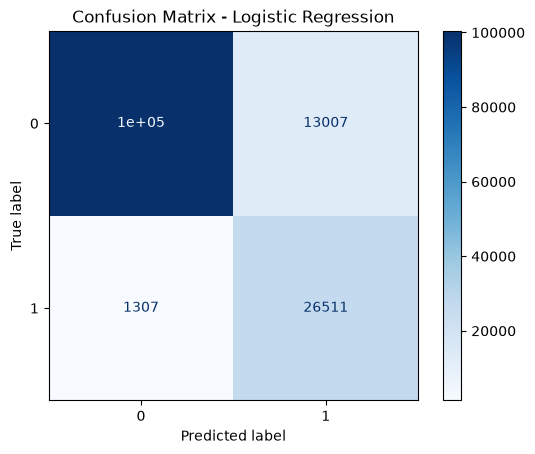


===== Decision Tree =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    113433
           1       0.95      0.99      0.97     27818

    accuracy                           0.99    141251
   macro avg       0.97      0.99      0.98    141251
weighted avg       0.99      0.99      0.99    141251

ROC-AUC: 0.9963112776905224


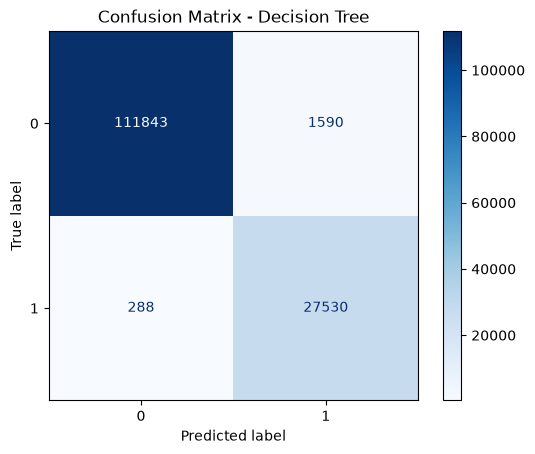


===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    113433
           1       0.95      0.99      0.97     27818

    accuracy                           0.99    141251
   macro avg       0.97      0.99      0.98    141251
weighted avg       0.99      0.99      0.99    141251

ROC-AUC: 0.9990822778975991


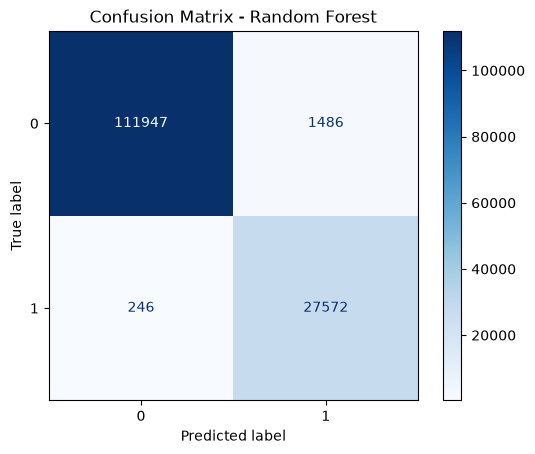


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113433
           1       0.95      0.96      0.96     27818

    accuracy                           0.98    141251
   macro avg       0.97      0.97      0.97    141251
weighted avg       0.98      0.98      0.98    141251

ROC-AUC: 0.9964521505889542


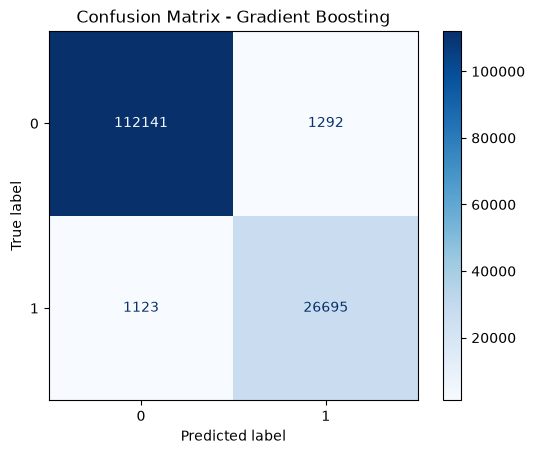


===== AdaBoost =====
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    113433
           1       0.97      0.84      0.90     27818

    accuracy                           0.96    141251
   macro avg       0.96      0.91      0.94    141251
weighted avg       0.96      0.96      0.96    141251

ROC-AUC: 0.9896473329432449


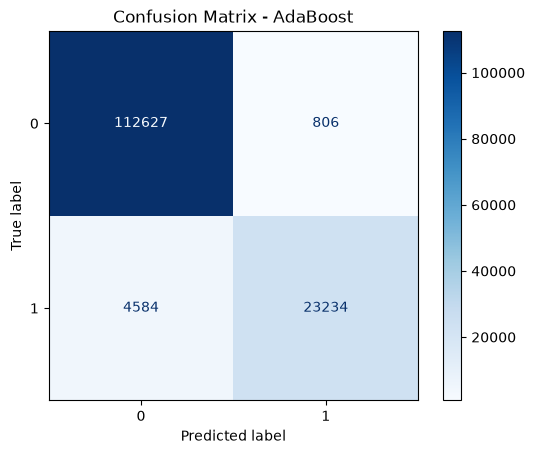


===== KNN =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113433
           1       0.97      0.95      0.96     27818

    accuracy                           0.99    141251
   macro avg       0.98      0.97      0.98    141251
weighted avg       0.99      0.99      0.99    141251

ROC-AUC: 0.9945820213194536


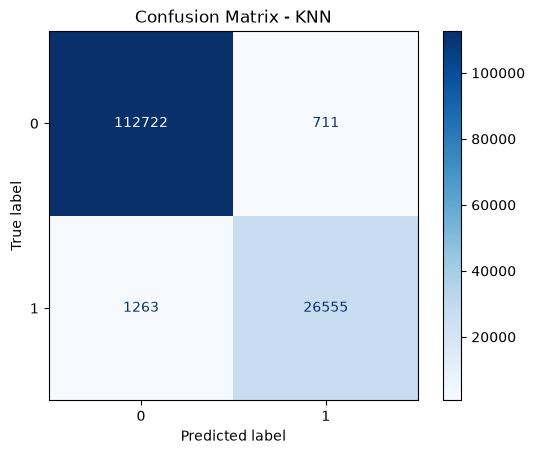


===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.99      0.69      0.81    113433
           1       0.43      0.97      0.60     27818

    accuracy                           0.75    141251
   macro avg       0.71      0.83      0.71    141251
weighted avg       0.88      0.75      0.77    141251

ROC-AUC: 0.8955807722876084


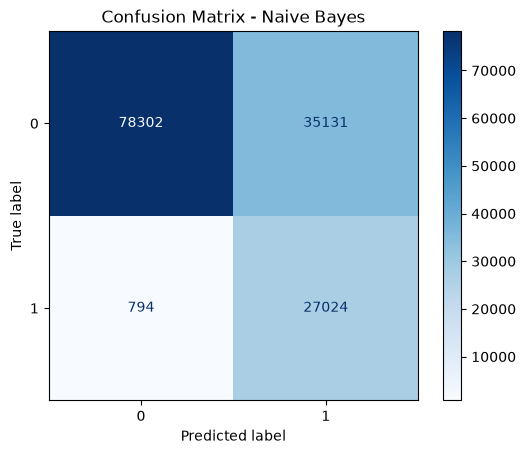


===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    113433
           1       0.95      0.99      0.97     27818

    accuracy                           0.99    141251
   macro avg       0.97      0.99      0.98    141251
weighted avg       0.99      0.99      0.99    141251

ROC-AUC: 0.9992554324222871


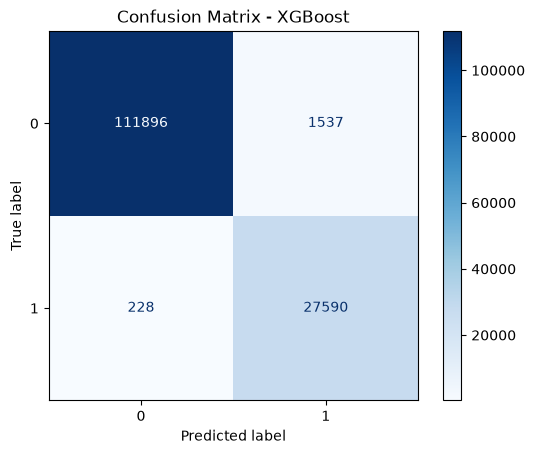

[LightGBM] [Info] Number of positive: 111272, number of negative: 453732
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8456
[LightGBM] [Info] Number of data points in the train set: 565004, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

===== LightGBM =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    113433
           1       0.94      0.99      0.97     27818

    accuracy                           0.99    141251
   macro avg       0.97      0.99      0.98    141251
weighted avg       0.99      0.99      0.99    141251

ROC-AUC: 0.9991452613583609


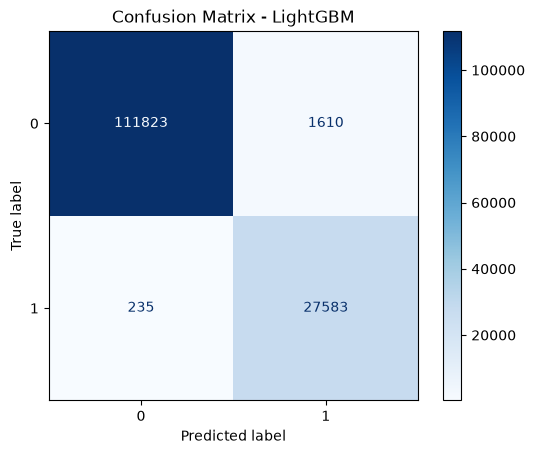

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_sec
0,Random Forest,0.987738,0.948861,0.991157,0.969548,0.999082,44.485179
1,XGBoost,0.987505,0.947231,0.991804,0.969005,0.999255,4.217578
2,LightGBM,0.986938,0.944850,0.991552,0.967638,0.999145,2.504641
3,Decision Tree,0.986705,0.945398,0.989647,0.967017,0.996311,9.568788
4,KNN,0.986025,0.973924,0.954598,0.964164,0.994582,0.101663
5,Gradient Boosting,0.982903,0.953836,0.959630,0.956724,0.996452,237.657640
6,AdaBoost,0.961841,0.966473,0.835215,0.896062,0.989647,61.134951
7,Logistic Regression,0.898663,0.670859,0.953016,0.787424,0.971495,6.108620
8,Naive Bayes,0.745666,0.434784,0.971457,0.600714,0.895581,0.264454


In [101]:
results_df, trained_models = run_models(
    models_dict=models,
    X=X,
    y=y,
    groups=groups,
    cv=group_kfold,
    strategy=IMBALANCE_STRATEGY
)
results_df


#### Visual comparison of all models across metrics

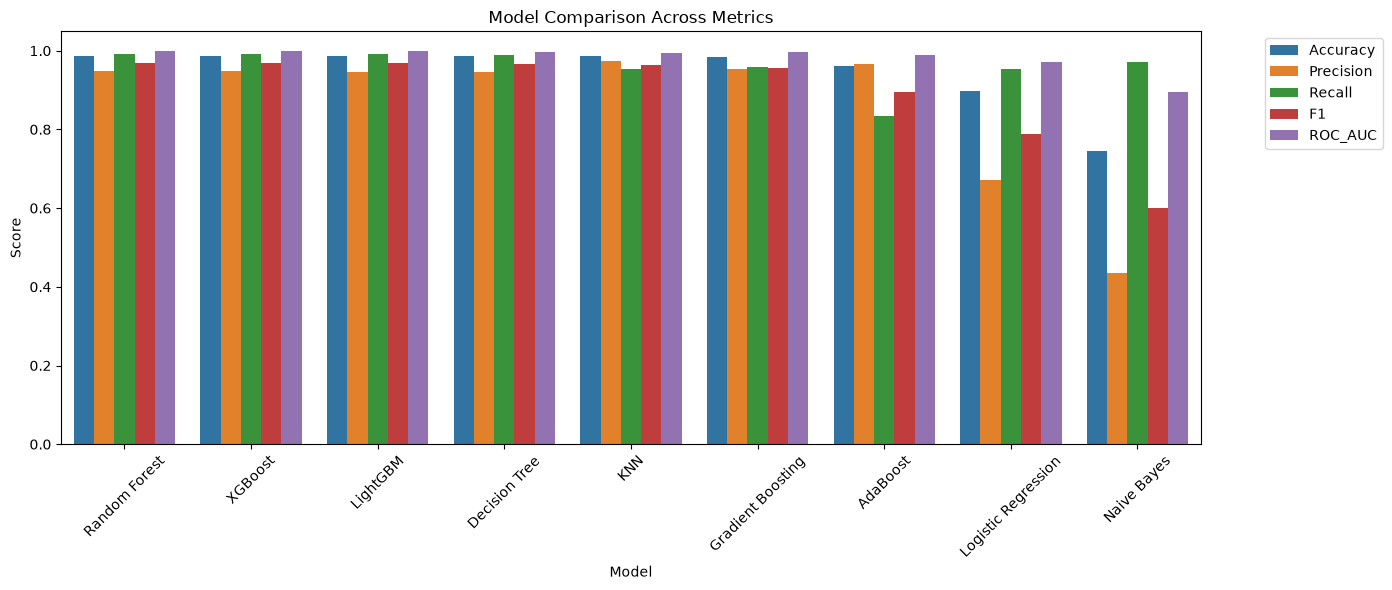

In [102]:
metrics_melted = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])

plt.figure(figsize=(14, 6))
sns.barplot(data=metrics_melted, x="Model", y="value", hue="variable")
plt.xticks(rotation=45)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [94]:
X_test_scaled.shape

(124787, 39)